<a href="https://colab.research.google.com/github/pravrud/CODESOFT_TASK4/blob/main/SMS_spam_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
#from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix



In [2]:
data = pd.read_csv('spam.csv', encoding='ISO-8859-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
data.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [5]:
data = data.drop(columns=data.columns[2:5])
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# Rename columns to meaningful names
data.columns = ['Category', 'Message']
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
# Check for null values
data.isnull().sum()

,0
Category,0
Message,0


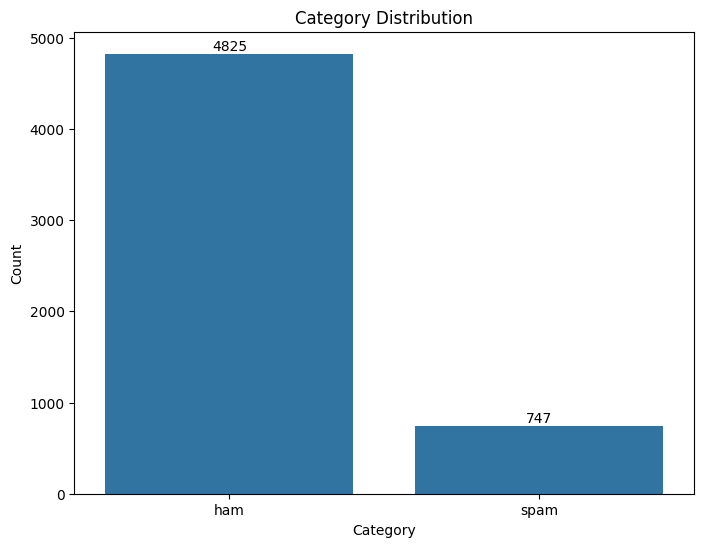

In [8]:
# Visualize category distribution
category_counts = data['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']
plt.figure(figsize=(8, 6))
sns.barplot(x='Category', y='Count', data=category_counts)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Category Distribution')


for i, count in enumerate(category_counts['Count']):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.show()

In [9]:
# Convert labels to binary: spam = 1, ham = 0
data['spam'] = (data['Category'] == 'spam').astype(int)
data

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will Ì_ b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


train and test of DATA

In [10]:
X_train, X_test, y_train, y_test = train_test_split(data['Message'], data['spam'], test_size=0.2, random_state=42)


In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train.values)

In [13]:
X_train_counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 58978 stored elements and shape (4457, 7735)>

Naive Bayes Method

In [14]:
model = MultinomialNB()
model.fit(X_train_counts, y_train)

X_test_counts = vectorizer.transform(X_test)
accuracy = model.score(X_test_counts, y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9839


Using pipeline

In [15]:
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

clf.fit(X_train, y_train)
print(f"Pipeline accuracy: {clf.score(X_test, y_test):.4f}")

Pipeline accuracy: 0.9839


In [16]:
# Pre‑trained model (same as above)
pretrained_model = model

new_sentences = [
    "Your account have 100 debited, is waiting to be collected. Simply text the password \"MIX\" to 85069 to verify. Get Usher and Britney. FML"
]

new_sentences_counts = vectorizer.transform(new_sentences)
predictions = pretrained_model.predict(new_sentences_counts)

for sentence, pred in zip(new_sentences, predictions):
    if pred == 1:
        print(f"{sentence} is a spam message.")
    else:
        print(f"{sentence} is not a spam message.")

Your account have 100 debited, is waiting to be collected. Simply text the password "MIX" to 85069 to verify. Get Usher and Britney. FML is a spam message.
